##👷🏿‍♂️ Unemployment Analysis in India

Unemployment is a critical economic indicator that reflects the health of a country’s economy. Understanding unemployment trends across different regions and time periods helps in making informed policy and business decisions.

The objective of this project is to analyze unemployment data across India and uncover patterns, trends, and insights using data visualization techniques.

## Objective
- Clean and preprocess the dataset  
- Analyze unemployment trends over time  
- Compare unemployment across regions  
- Generate meaningful insights using visualizations  

#### Tools Used
- Python  
- Pandas, NumPy  
- Matplotlib, Seaborn  

In [3]:
## Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
## Loading Dataset
df = pd.read_csv('Unemployment in India.xls')
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


## Dataset Overview

The dataset contains monthly unemployment statistics across different states in India.

Key features:
*   State: State-wise unemployment rate
*   Date: Monthly time-series data
*   Unemployment_Rate: Percentage of unemployed individuals
*   Employed: Number of employed individuals
*   Labour_Participation_Rate: Percentage of population actively participating in the workforce
*   Area: Urban or Rural classification

The dataset is particularly useful for analyzing the impact of Covid-19 on employment trends.

In [5]:
## Initial Data Exploration
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [6]:
## Data Cleaning
# Remove extra spaces
df.columns = df.columns.str.strip()

# Rename columns properly
df.rename(columns={
    'Region': 'State',
    'Date': 'Date',
    'Frequency': 'Frequency',
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate'
}, inplace=True)

df.head()

,State,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


## Data Cleaning

The dataset contains inconsistent column names with extra spaces and long labels.

To improve readability and ensure smooth analysis, column names are cleaned and renamed into a structured format.

In [7]:
## Date Formatting
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   State                      740 non-null    object        
 1   Date                       740 non-null    datetime64[ns]
 2   Frequency                  740 non-null    object        
 3   Unemployment_Rate          740 non-null    float64       
 4   Employed                   740 non-null    float64       
 5   Labour_Participation_Rate  740 non-null    float64       
 6   Area                       740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 42.1+ KB


## Handling Missing Values

The dataset contains a small number of missing values.

Since the missing data is minimal, these rows are removed to ensure data consistency and avoid issues during analysis.

In [8]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   State                      740 non-null    object        
 1   Date                       740 non-null    datetime64[ns]
 2   Frequency                  740 non-null    object        
 3   Unemployment_Rate          740 non-null    float64       
 4   Employed                   740 non-null    float64       
 5   Labour_Participation_Rate  740 non-null    float64       
 6   Area                       740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


## Covid-19 Impact Segmentation

To analyze the effect of Covid-19 on unemployment, the dataset is divided into two periods:
- Pre-Covid (before 2020)  
- During-Covid (2020 and after)  

This allows comparison of unemployment trends before and during the pandemic.

In [9]:
df['Year'] = df['Date'].dt.year

# Create Covid period column
df['Covid_Period'] = df['Year'].apply(lambda x: 'Pre-Covid' if x < 2020 else 'During-Covid')

df.head()

,State,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area,Year,Covid_Period
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,Pre-Covid
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019,Pre-Covid
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019,Pre-Covid
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019,Pre-Covid
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019,Pre-Covid


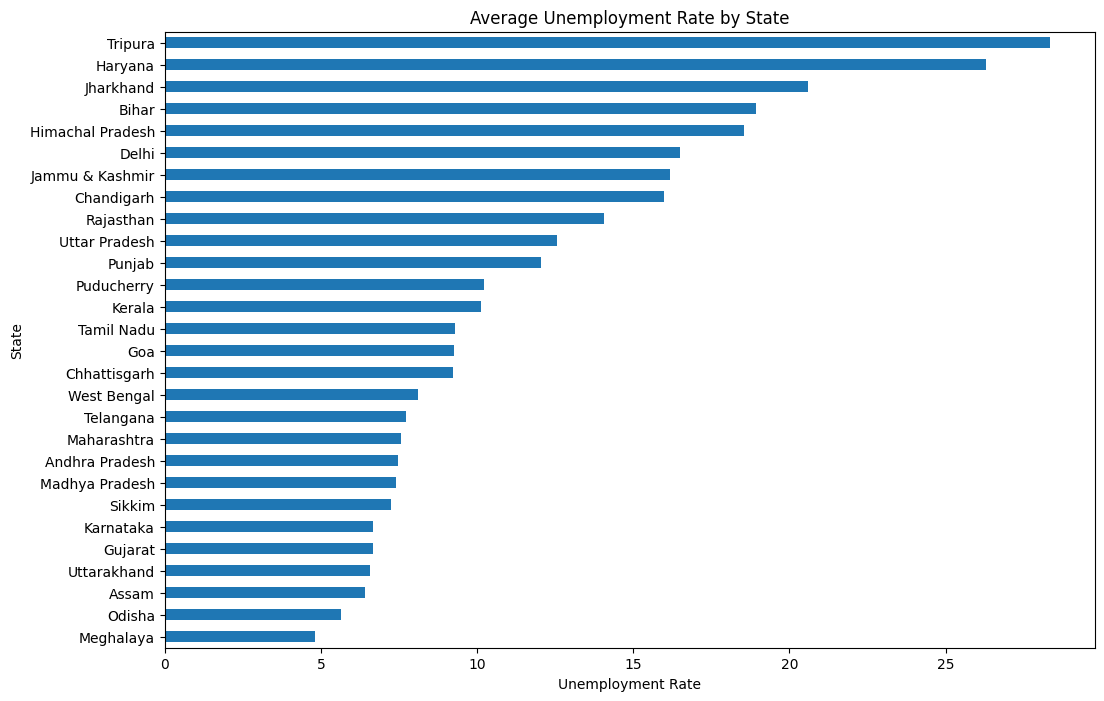

In [10]:
## Average Unemployment by State
state_unemp = df.groupby('State')['Unemployment_Rate'].mean().sort_values()

plt.figure(figsize=(12,8))
state_unemp.plot(kind='barh')
plt.title('Average Unemployment Rate by State')
plt.xlabel('Unemployment Rate')
plt.show()

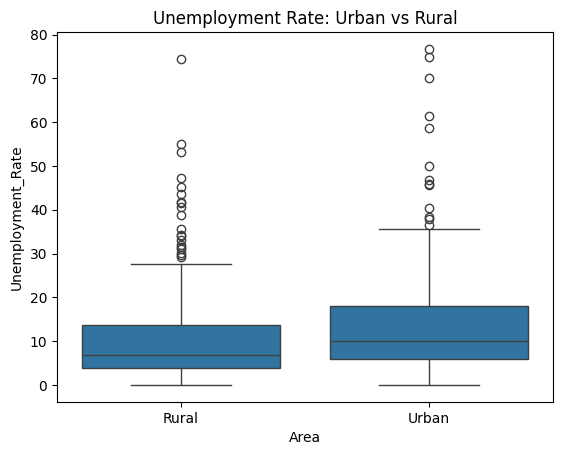

In [11]:
## Urban vs Rural Unemployment
sns.boxplot(x='Area', y='Unemployment_Rate', data=df)
plt.title('Unemployment Rate: Urban vs Rural')
plt.show()

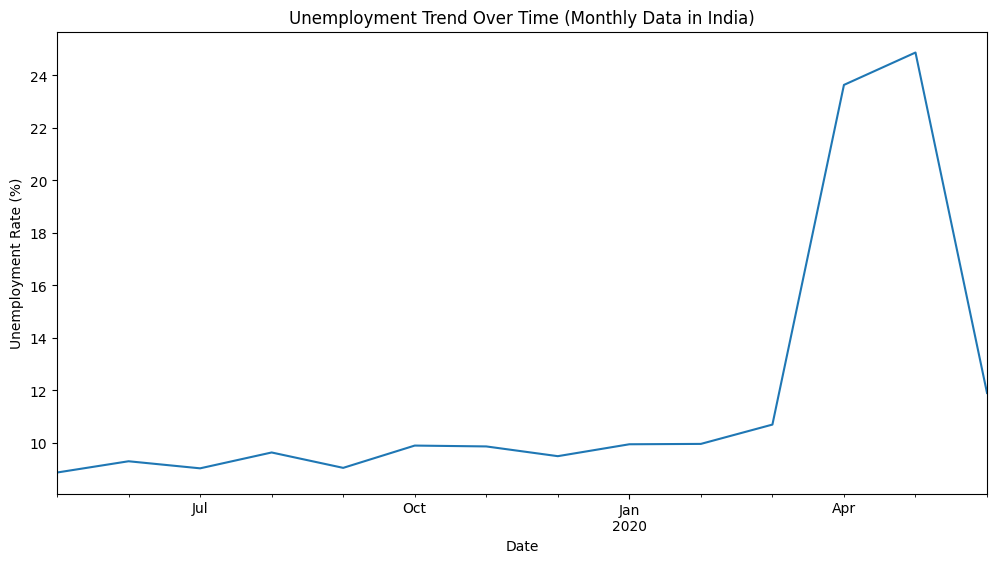

In [12]:
## Unemployment Trend Over Time
monthly_trend = df.groupby('Date')['Unemployment_Rate'].mean()
plt.figure(figsize=(12,6))
monthly_trend.plot()
plt.title('Unemployment Trend Over Time (Monthly Data in India)')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.show()

### Trend Analysis

- Unemployment rates show a clear spike during 2020  
- This corresponds with the Covid-19 pandemic period  
- After the peak, the trend gradually stabilizes  

This reflects a disruption followed by recovery in employment.

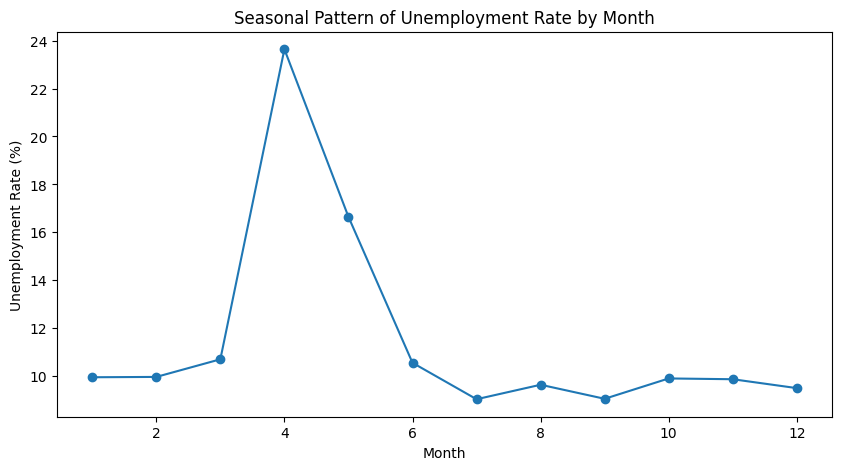

In [13]:
## Monthly Unemployment Pattern
df['Month'] = df['Date'].dt.month

monthly_pattern = df.groupby('Month')['Unemployment_Rate'].mean()

plt.figure(figsize=(10,5))
monthly_pattern.plot(marker='o')
plt.title('Seasonal Pattern of Unemployment Rate by Month')
plt.xlabel('Month')
plt.ylabel('Unemployment Rate (%)')
plt.show()

### Seasonal & Pattern Insights

- Monthly averages show some variation but no consistent repeating seasonal pattern  
- The absence of clear cyclic behavior suggests unemployment is influenced more by external shocks  
- The spike during 2020 confirms that events like Covid-19 dominate unemployment trends rather than seasonality   

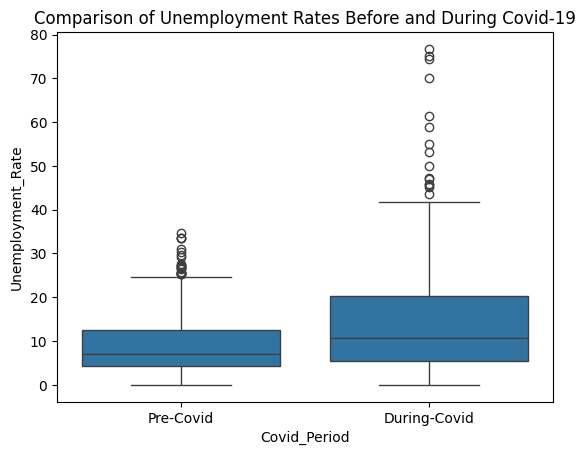

In [14]:
## Impact of Covid-19 on Unemployment
sns.boxplot(x='Covid_Period', y='Unemployment_Rate', data=df)
plt.title('Comparison of Unemployment Rates Before and During Covid-19')
plt.show()

### Covid Impact Insights

- Unemployment increased significantly during the Covid period  
- Economic disruption and lockdowns contributed to job losses  
- Variability increased, showing instability in employment  

The sharp increase in unemployment during Covid aligns with nationwide lockdown measures, which significantly disrupted economic activity.

## Key Insights

- Unemployment rates vary significantly across states, highlighting regional economic disparities  
- Temporal trends indicate fluctuations, which may be influenced by economic cycles or external events  
- Labour participation rate plays a crucial role in interpreting unemployment levels, as higher participation increases competition in the job market  
- Urban and rural areas show different unemployment patterns, reflecting differences in job availability and economic structure  

Overall, unemployment is not uniform and depends on both geographic and economic factors.

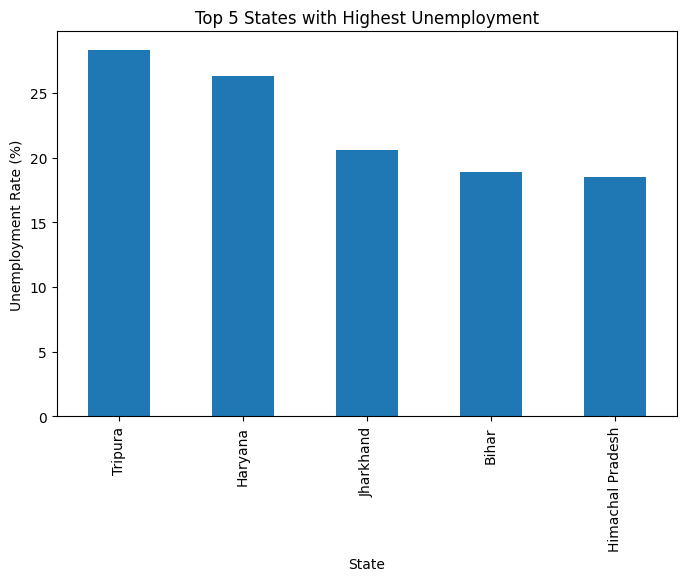

In [15]:
## Top 5 States with Highest Unemployment
top_states = df.groupby('State')['Unemployment_Rate'].mean().sort_values(ascending=False).head(5)

top_states.plot(kind='bar', figsize=(8,5))
plt.title('Top 5 States with Highest Unemployment')
plt.ylabel('Unemployment Rate (%)')
plt.show()

This analysis is based on a limited dataset and may not capture all real-world economic factors affecting unemployment.

## Policy Insights

- Targeted employment programs are needed in states with consistently high unemployment  
- Emergency economic support is crucial during crises such as Covid-19  
- Strengthening labour market resilience can reduce the impact of future shocks  
- Increasing labour participation can improve overall economic stability  

These insights highlight the importance of proactive and data-driven policy decisions.

## Conclusion

This project analyzed unemployment trends in India with a focus on the impact of Covid-19.

Key findings:
- Unemployment increased significantly during the Covid period  
- Regional disparities highlight uneven economic development  
- Time-based analysis reveals the effect of external shocks  
- Urban and rural differences reflect structural economic variations  

The analysis demonstrates how data can support economic understanding and policy decisions.

The dataset is limited and may not capture all real-world factors affecting unemployment.

The sharp rise in unemployment during 2020 highlights the immediate economic impact of the Covid-19 pandemic.